#### Objective
Learn how PowerTransformer helps normalize skewed data.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as mt
import seaborn as sns
import scipy.stats as stats

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import PowerTransformer

In [3]:
df = pd.read_csv('/content/wows_ship_stats.csv')


In [4]:
df.head(5)

,Ship,Tier,Class,Nation,Players,Battles,Base XP,Damage,Frags,Win rate,Capture,Defence,Spotting,Potential,Aircraft,Survival rate
0,Patrie,11,BB,France,9092,337170,1388,125865,0.936,0.512,2.13,4.74,19358,1809099,5.60,0.426
1,Hannover,11,BB,Germany,16503,319701,1150,86471,0.633,0.485,1.81,4.16,20080,1930510,6.42,0.240
2,Satsuma,11,BB,Japan,40417,1562549,1246,112667,0.809,0.499,1.32,3.21,17402,1730502,4.15,0.469
3,Devastation,11,BB,U.K.,5660,140172,1323,127807,0.766,0.499,1.98,4.78,20776,1896948,4.71,0.499
4,Maine,11,BB,U.S.A.,10744,352970,1344,114812,0.890,0.513,2.32,4.11,22194,2078203,7.70,0.445


In [5]:
df.isnull().sum()

,0
Ship,0
Tier,0
Class,0
Nation,0
Players,0
Battles,0
Base XP,0
Damage,0
Frags,0
Win rate,0


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 925 entries, 0 to 924
Data columns (total 16 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Ship           925 non-null    object 
 1   Tier           925 non-null    int64  
 2   Class          925 non-null    object 
 3   Nation         925 non-null    object 
 4   Players        925 non-null    int64  
 5   Battles        925 non-null    int64  
 6   Base XP        925 non-null    int64  
 7   Damage         925 non-null    int64  
 8   Frags          925 non-null    float64
 9   Win rate       925 non-null    float64
 10  Capture        925 non-null    float64
 11  Defence        925 non-null    float64
 12  Spotting       925 non-null    int64  
 13  Potential      925 non-null    int64  
 14  Aircraft       925 non-null    float64
 15  Survival rate  925 non-null    float64
dtypes: float64(6), int64(7), object(3)
memory usage: 115.8+ KB


In [7]:
df.describe()

,Tier,Players,Battles,Base XP,Damage,Frags,Win rate,Capture,Defence,Spotting,Potential,Aircraft,Survival rate
count,925.000000,925.000000,9.250000e+02,925.000000,925.000000,925.000000,925.000000,925.000000,925.000000,925.000000,9.250000e+02,925.000000,925.000000
mean,7.339459,36561.282162,1.045073e+06,975.094054,49264.187027,0.804107,0.516699,11.309276,8.213459,22148.997838,7.128088e+05,3.689265,0.371503
std,2.342301,48974.272885,1.767742e+06,223.569790,23863.731582,0.384416,0.032881,11.585104,6.976746,17686.419281,4.358737e+05,3.296722,0.116186
min,1.000000,1.000000,1.000000e+00,468.000000,9487.000000,0.384000,0.000000,0.000000,0.000000,143.000000,3.611100e+04,0.000000,0.000000
25%,6.000000,7385.000000,9.483000e+04,822.000000,31164.000000,0.614000,0.499000,3.590000,5.130000,11462.000000,3.723430e+05,1.320000,0.296000
50%,8.000000,17844.000000,3.460050e+05,1008.000000,44287.000000,0.716000,0.513000,5.990000,7.050000,17756.000000,6.162530e+05,3.370000,0.349000
75%,9.000000,47185.000000,1.109821e+06,1139.000000,62895.000000,0.860000,0.531000,15.160000,9.280000,26158.000000,1.026331e+06,5.120000,0.415000
max,11.000000,302858.000000,1.832192e+07,1451.000000,145521.000000,4.906000,0.720000,48.160000,102.370000,120030.000000,2.329626e+06,27.880000,0.830000


In [8]:
x = df.iloc[:,5:13]
y = df.iloc[:,-1]

In [9]:
x_train,x_test,y_train,y_test = train_test_split(x,y,
                                                 test_size = 0.2,
                                                 random_state = 42)

In [10]:
x_train.head()

,Battles,Base XP,Damage,Frags,Win rate,Capture,Defence,Spotting
97,16634,1079,75925,0.614,0.502,2.90,4.72,18934
227,707982,1027,56205,0.837,0.523,3.65,4.52,11508
692,34188,586,16683,2.549,0.396,1.70,40.83,568
587,1509578,803,32557,0.632,0.535,5.15,4.68,13931
885,783241,677,17676,0.615,0.501,22.98,6.55,14301


In [11]:
# Standard Scaler
scal = StandardScaler()
x_train_scaled = scal.fit_transform(x_train)
x_test_scaled = scal.transform(x_test)

In [12]:
lr = LinearRegression()

lr.fit(x_train_scaled,y_train)

y_pred = lr.predict(x_test_scaled)

r2score = r2_score(y_test,y_pred)

print(r2score)

0.6510495768395613


In [13]:
lr1 = LinearRegression()

np.mean(cross_val_score(lr1,x_test,y_test,scoring = 'r2'))

np.float64(0.592475463353053)

In [14]:
x_train_scaled = pd.DataFrame(
    x_train_scaled,
    columns=x_train.columns
)

/tmp/ipykernel_13954/1362172743.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(x_train_scaled[col])
/tmp/ipykernel_13954/1362172743.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(x_train_scaled[col])
/tmp/ipykernel_13954/1362172743.py:4: UserWarning: 

`distplot` is a deprecated functi

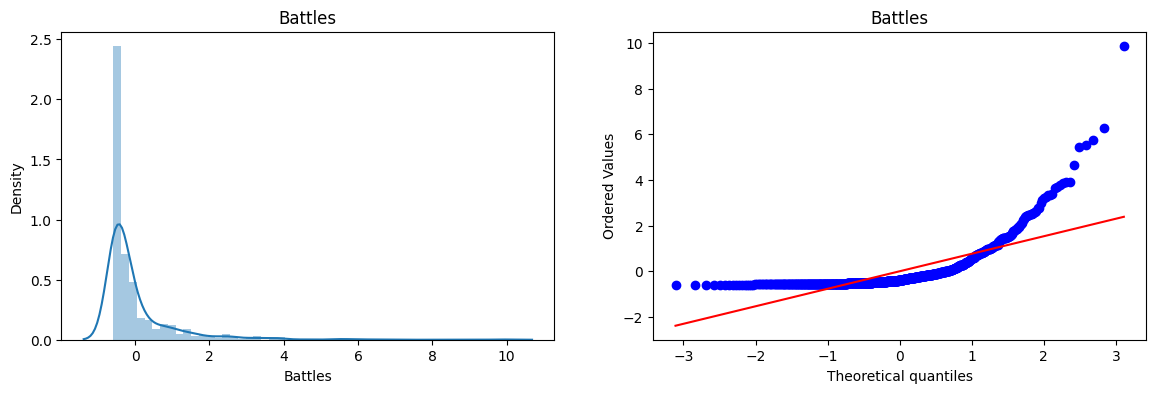

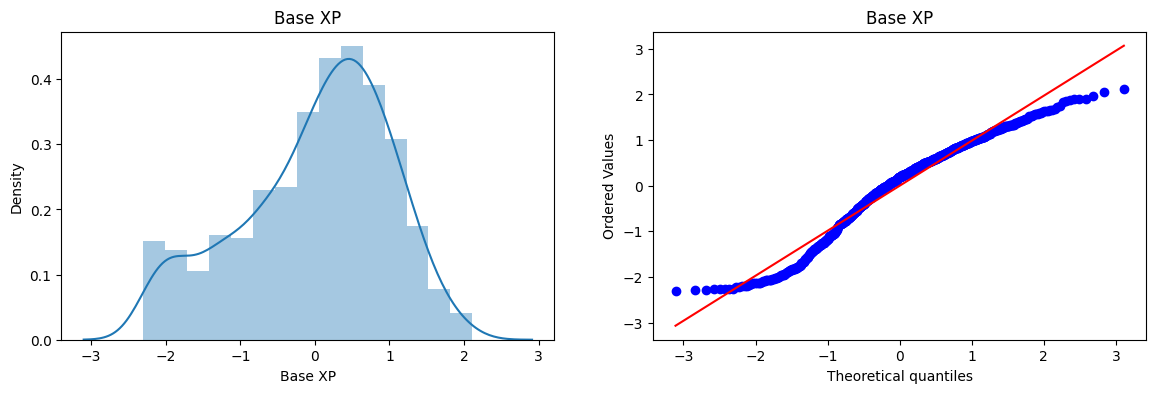

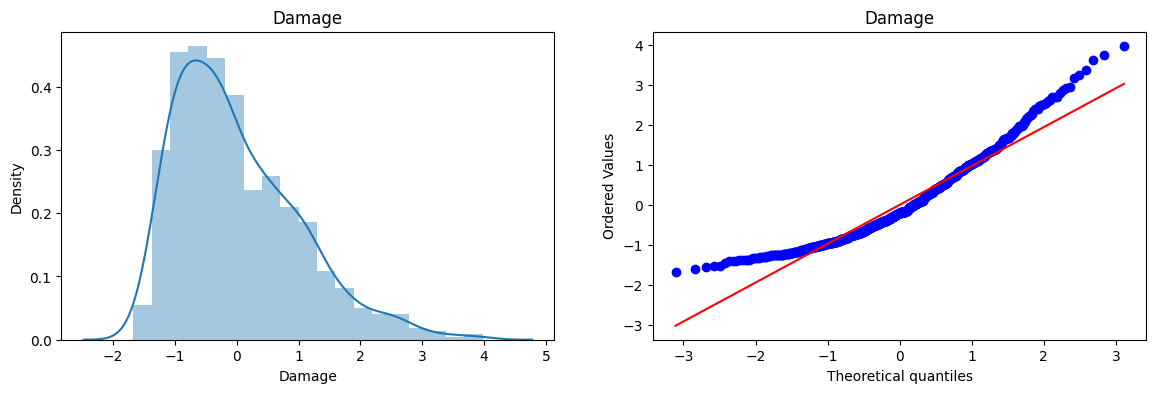

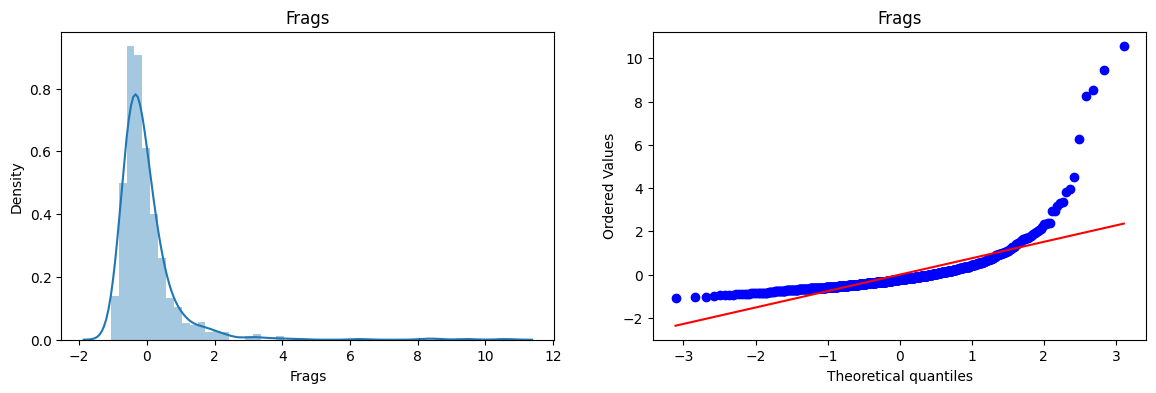

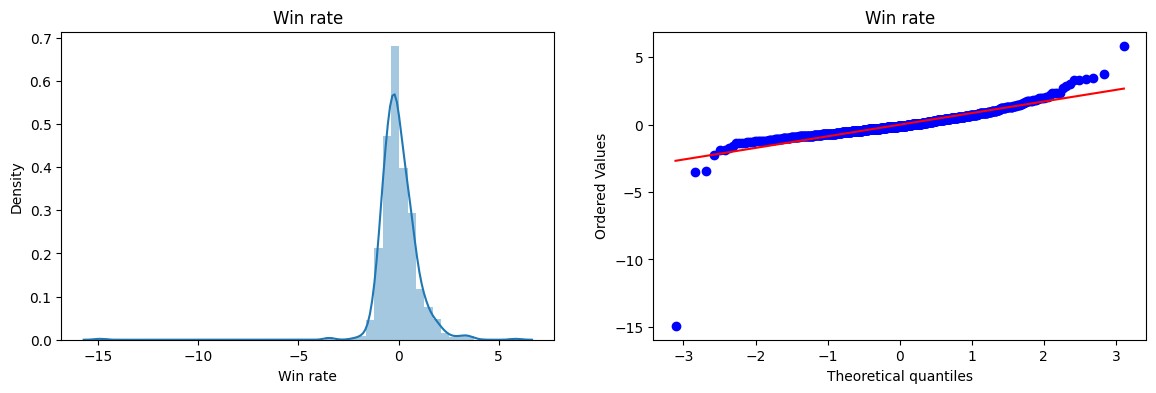

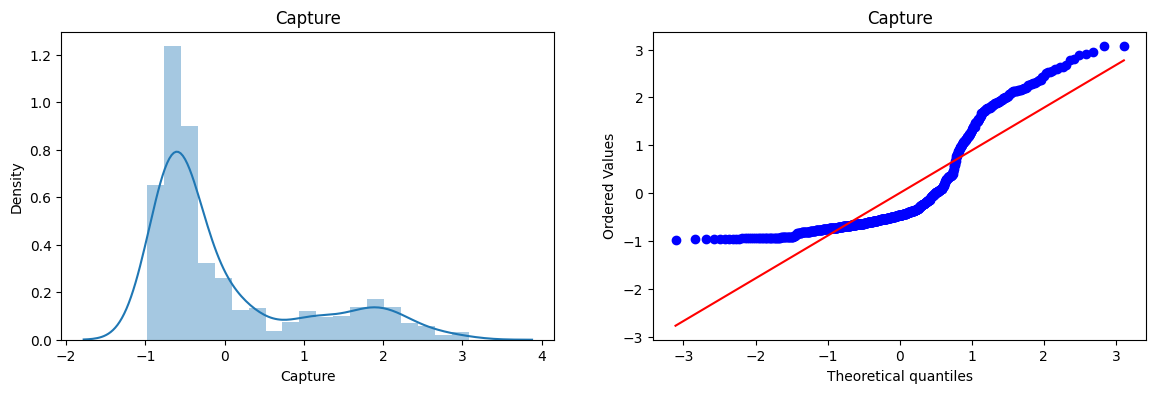

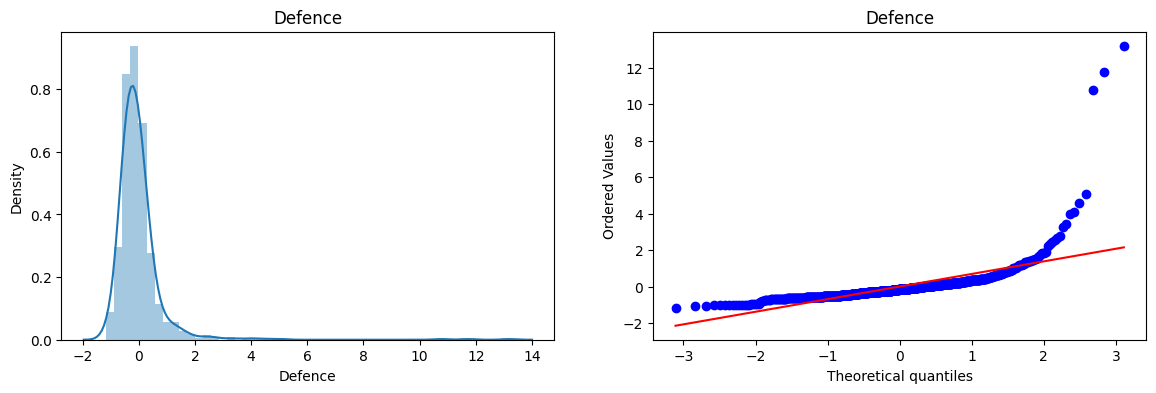

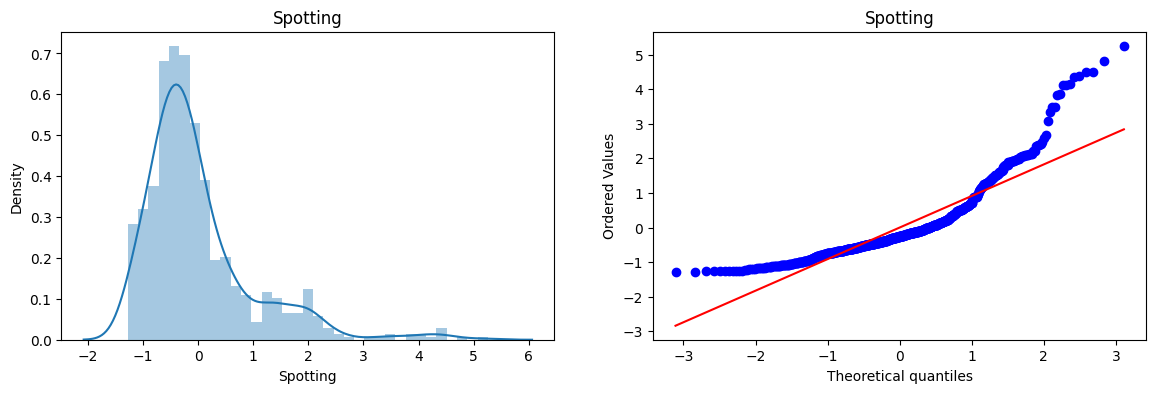

In [15]:
for col in x_train.columns:
  mt.figure(figsize = (14,4))
  mt.subplot(1,2,1)
  sns.distplot(x_train_scaled[col])
  mt.title(col)

  mt.subplot(1,2,2)
  stats.probplot(x_train_scaled[col],dist='norm',plot = mt)
  mt.title(col)
  mt.show

In [16]:
# Min_max Scaler

x_train_scaled1 = MinMaxScaler().fit_transform(x_train)
x_test_scaled1 = MinMaxScaler().fit_transform(x_test)

In [17]:
lr = LinearRegression()

lr.fit(x_test_scaled1,y_test)

y_pred = lr.predict(x_test_scaled1)

print('R2 score is :',r2_score(y_test,y_pred))

R2 score is : 0.6720996927826961


In [18]:
lr2 = LinearRegression()

np.mean(cross_val_score(lr,x_test_scaled1,y_test,scoring = 'r2'))

np.float64(0.5924754633530185)

In [19]:
x_train_scaled1 = pd.DataFrame(
    x_train_scaled1,
    columns=x_train.columns
)

/tmp/ipykernel_13954/4164856020.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(x_train_scaled1[col])
/tmp/ipykernel_13954/4164856020.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(x_train_scaled1[col])
/tmp/ipykernel_13954/4164856020.py:4: UserWarning: 

`distplot` is a deprecated func

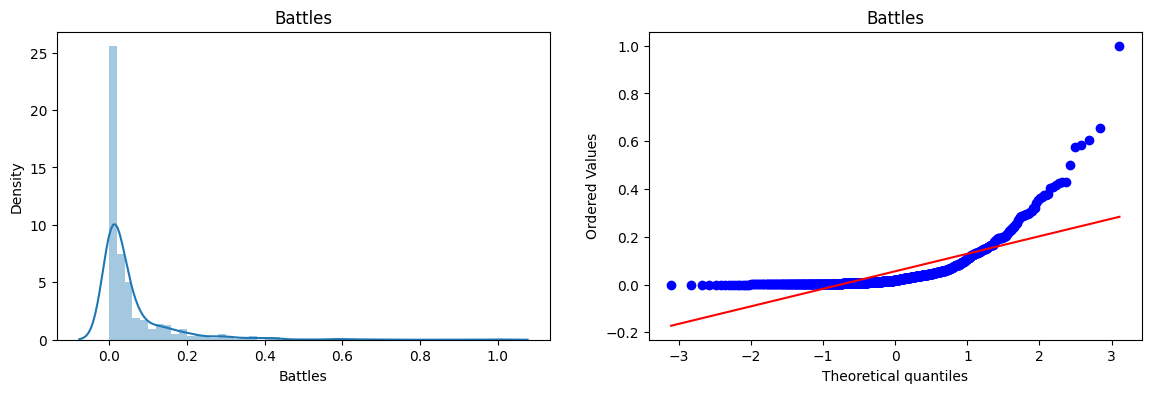

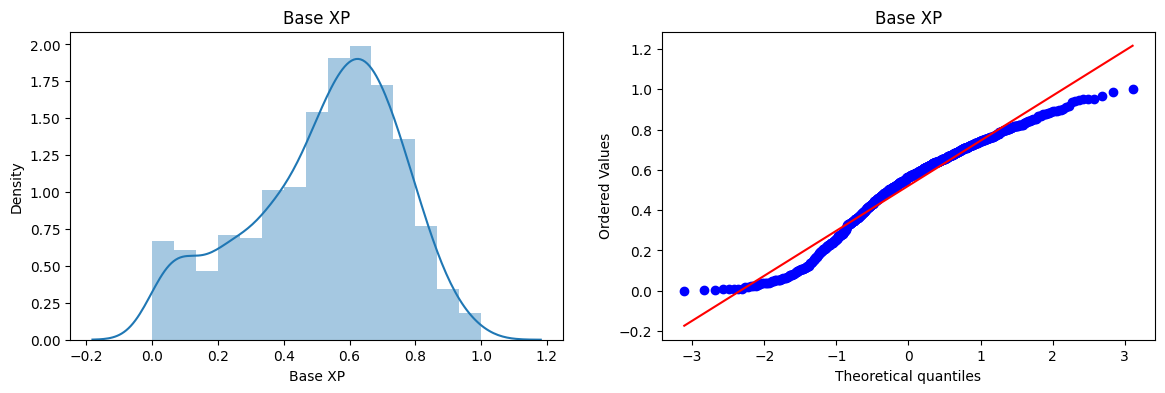

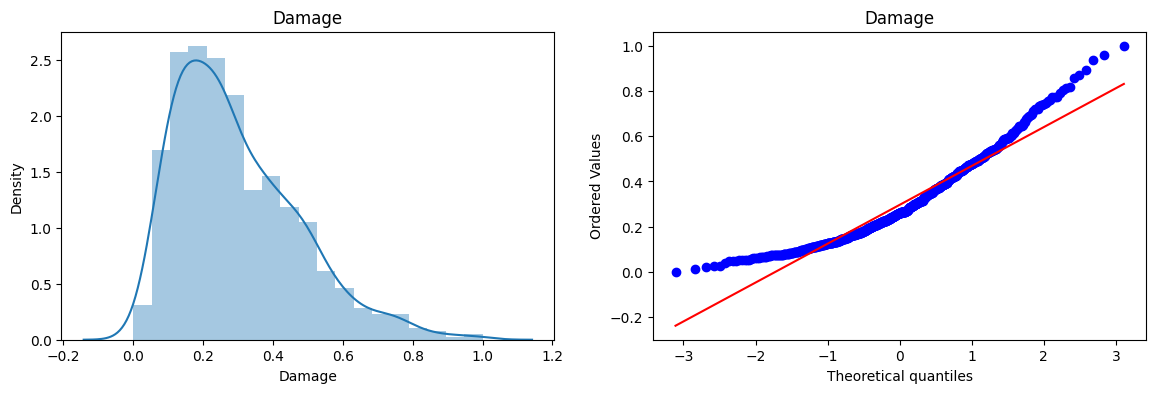

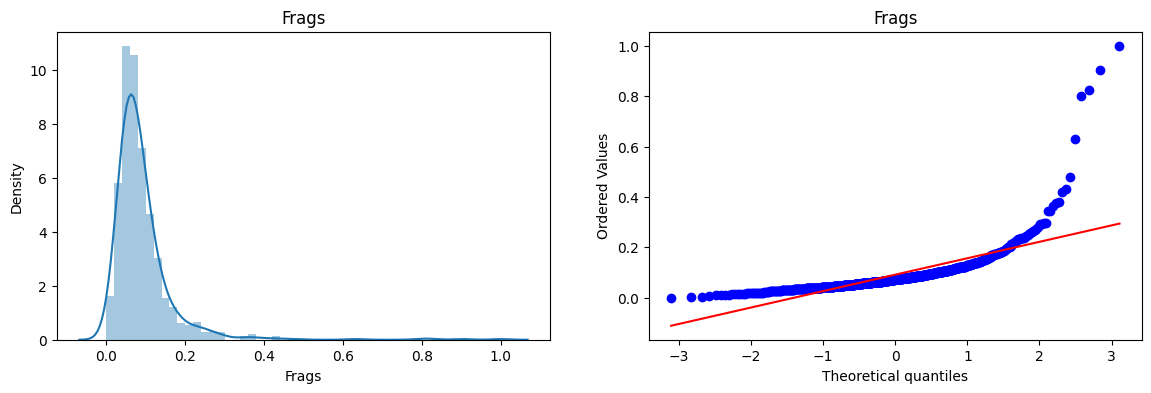

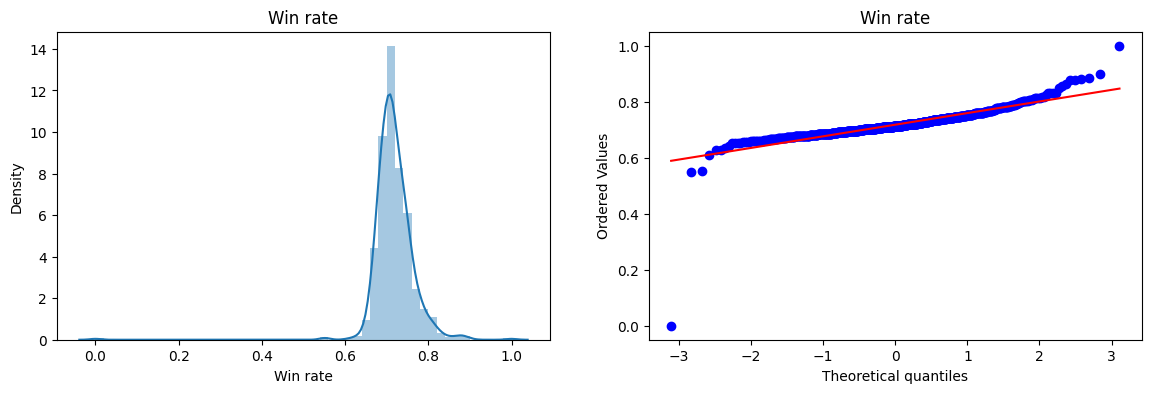

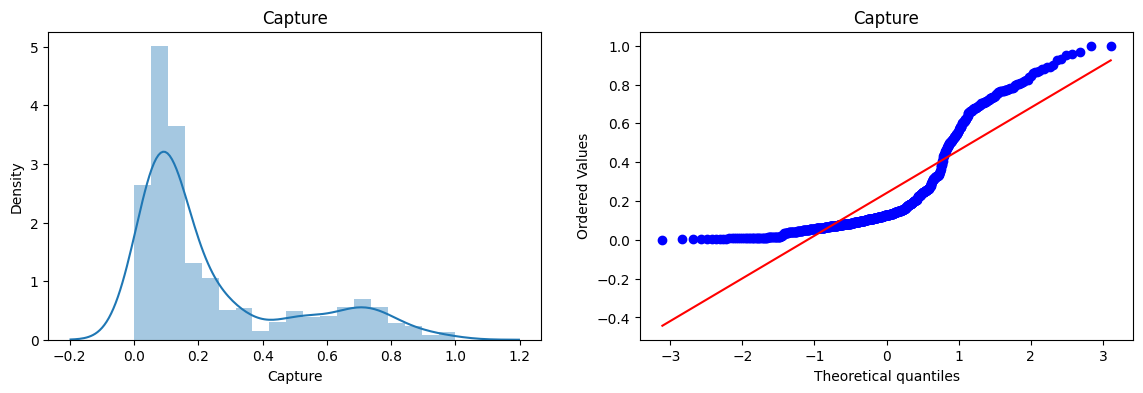

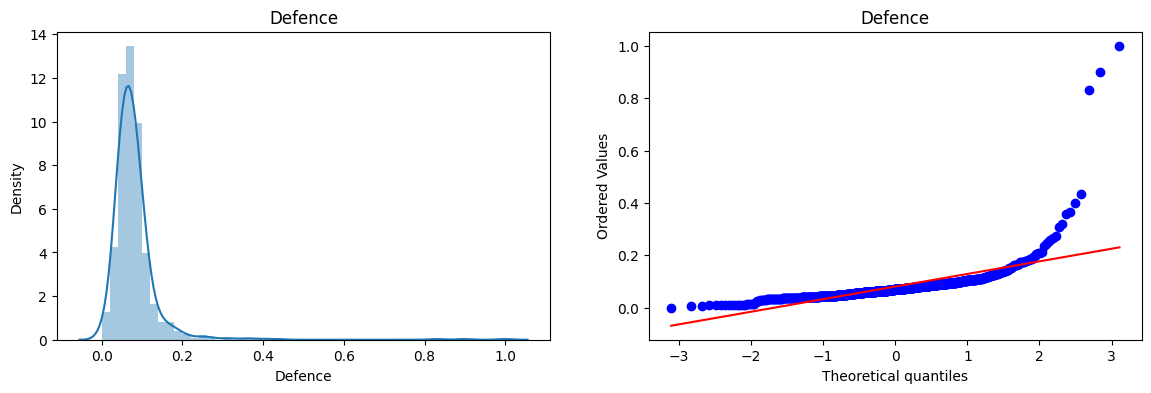

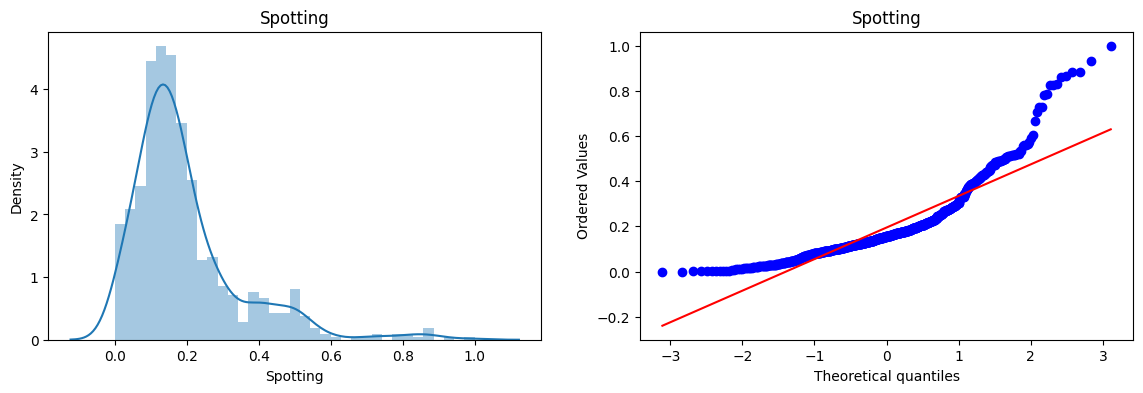

In [20]:
for col in x_train.columns:
  mt.figure(figsize = (14,4))
  mt.subplot(1,2,1)
  sns.distplot(x_train_scaled1[col])
  mt.title(col)

  mt.subplot(1,2,2)
  stats.probplot(x_train_scaled1[col],dist='norm',plot = mt)
  mt.title(col)
  mt.show

# Applying Box-Pox Transformer

In [21]:
pt = PowerTransformer(method='box-cox')
x_train_transformed = pt.fit_transform(x_train_scaled1 + 0.000001)
x_test_transformed = pt.transform(x_test_scaled1 + 0.000001)

pd.DataFrame({'cols':x_train.columns,'Box_Cox_lamdas':pt.lambdas_})

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PowerTransformer was fitted with feature names
  warnings.warn(


,cols,Box_Cox_lamdas
0,Battles,0.127925
1,Base XP,1.091062
2,Damage,0.371495
3,Frags,0.191325
4,Win rate,1.873332
5,Capture,0.190491
6,Defence,0.222452
7,Spotting,0.347783


In [22]:
lr = LinearRegression()

lr.fit(x_train_transformed,y_train)

y_pred = lr.predict(x_test_transformed)

print("R2 Score is :",r2_score(y_test,y_pred))


R2 Score is : -0.6057967285075467


In [23]:
# Convert numpy array into dataframe to see plot
x_train_transformed = pd.DataFrame(
    x_train_transformed,
    columns=x_train.columns
)

/tmp/ipykernel_13954/1001857612.py:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(x_train_scaled1[col])
/tmp/ipykernel_13954/1001857612.py:9: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(x_train_transformed[col])
/tmp/ipykernel_13954/1001857612.py:5: UserWarning: 

`distplot` is a deprecated 

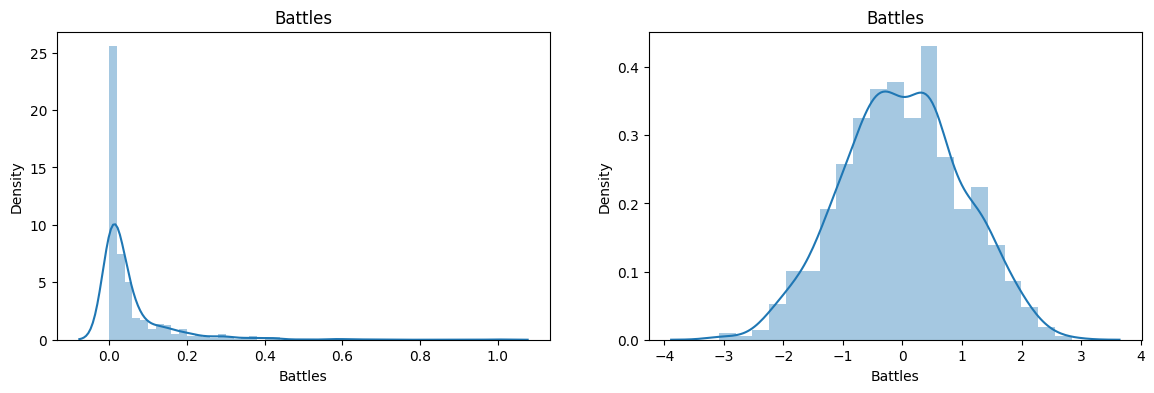

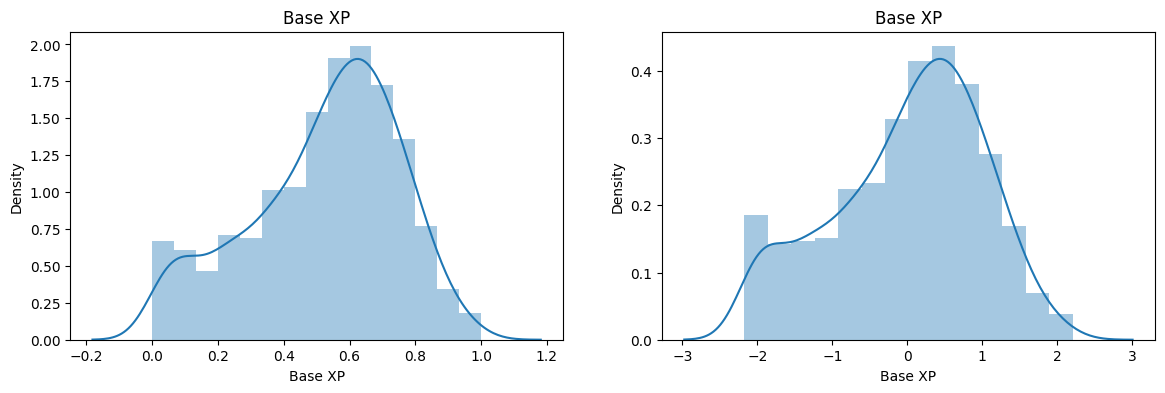

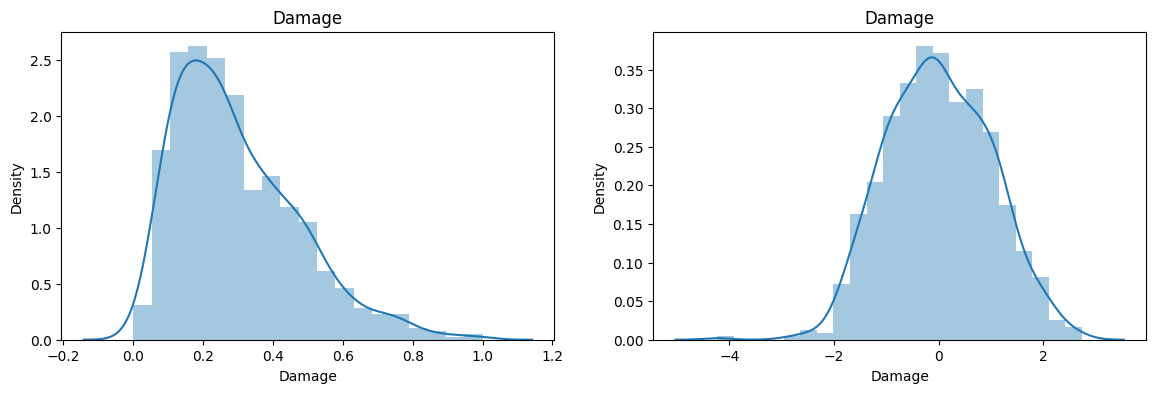

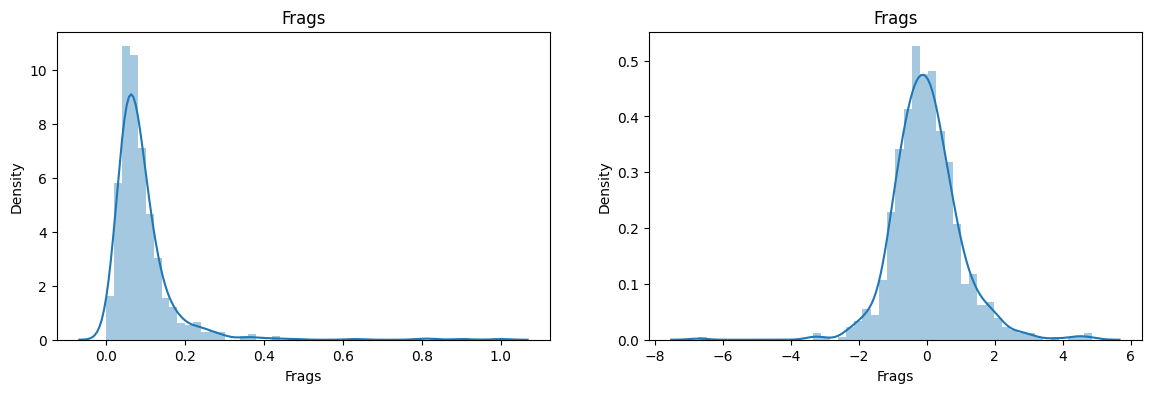

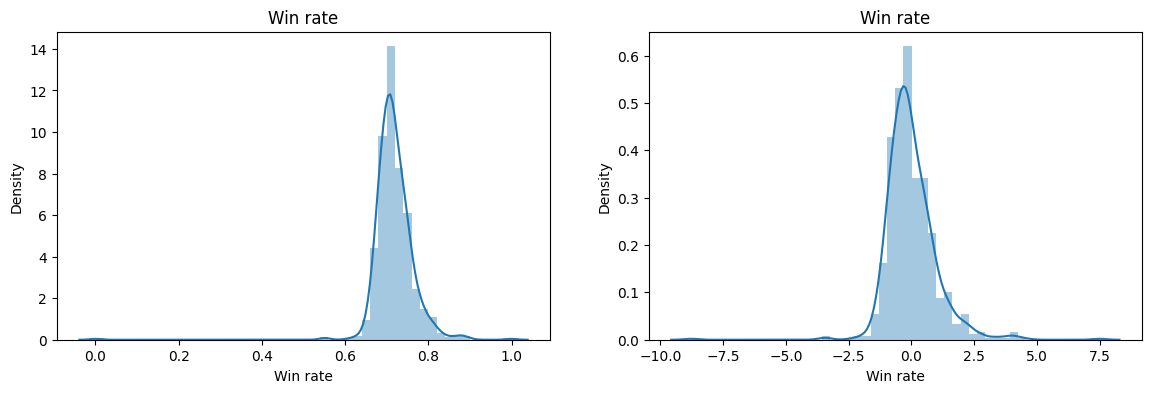

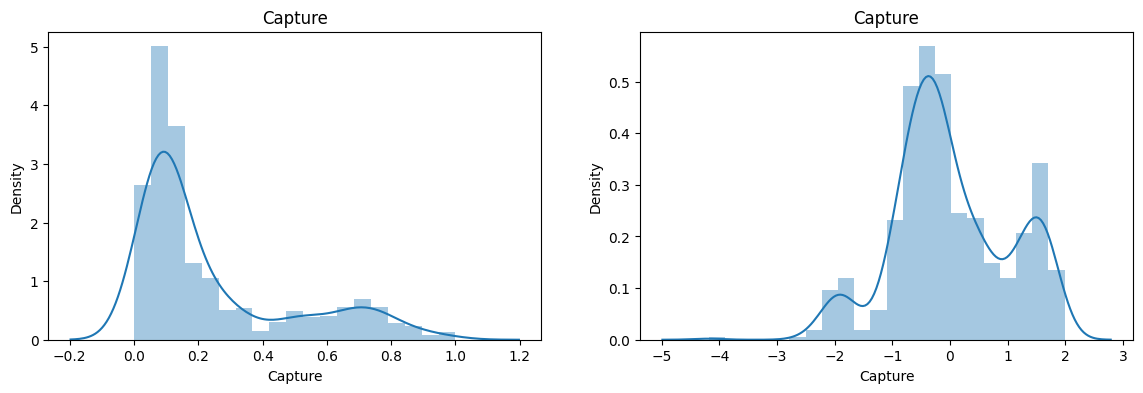

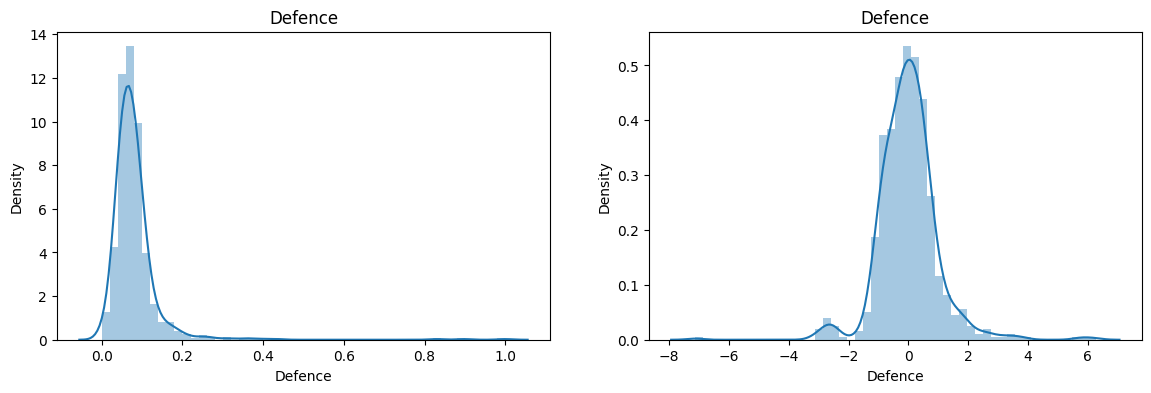

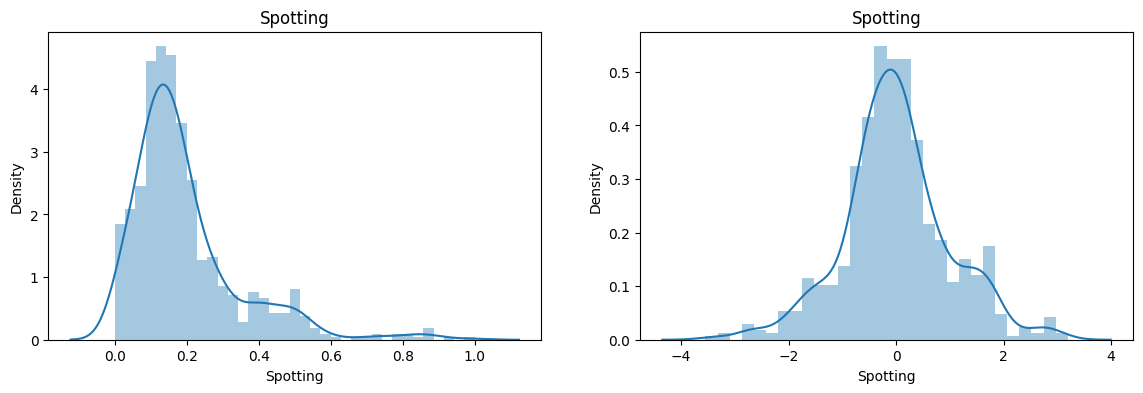

In [24]:
# Before and after camparison for box-cox plot
for col in x_train.columns:
  mt.figure(figsize = (14,4))
  mt.subplot(1,2,1)
  sns.distplot(x_train_scaled1[col])
  mt.title(col)

  mt.subplot(1,2,2)
  sns.distplot(x_train_transformed[col])
  mt.title(col)
  mt.show

# Yeo - Johnson Tranformer

In [25]:
pt2 = PowerTransformer(method='yeo-johnson')
x_train_transformed2 = pt2.fit_transform(x_train_scaled1)
x_test_transformed2 = pt2.fit_transform(x_test_scaled1)

In [26]:
lr = LinearRegression()

lr.fit(x_train_transformed2,y_train)

y_pred2 = lr.predict(x_test_transformed2)

print('R2 Score :',r2_score(y_test,y_pred))

R2 Score : -0.6057967285075467


In [27]:
# Convert numpy array into dataframe to see plot
x_train_transformed2 = pd.DataFrame(
    x_train_transformed2,
    columns=x_train.columns
)

In [28]:

pd.DataFrame({'cols':x_train_transformed2.columns,'Yeo-Johnson':pt2.lambdas_})

,cols,Yeo-Johnson
0,Battles,-9.634896
1,Base XP,1.226578
2,Damage,-2.065773
3,Frags,-7.152704
4,Win rate,-1.619189
5,Capture,-4.854678
6,Defence,-5.479604
7,Spotting,-4.835962


In [29]:
# Applying crossval score

pt = PowerTransformer()
x_transformed2 = pt.fit_transform(x)

lr1 = LinearRegression()
np.mean(cross_val_score(lr1,x_transformed2,y,scoring='r2'))

np.float64(0.3340088700300462)

/tmp/ipykernel_13954/3912702517.py:6: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(x_train_scaled1[col])
/tmp/ipykernel_13954/3912702517.py:10: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(x_train_transformed2[col])
/tmp/ipykernel_13954/3912702517.py:6: UserWarning: 

`distplot` is a deprecate

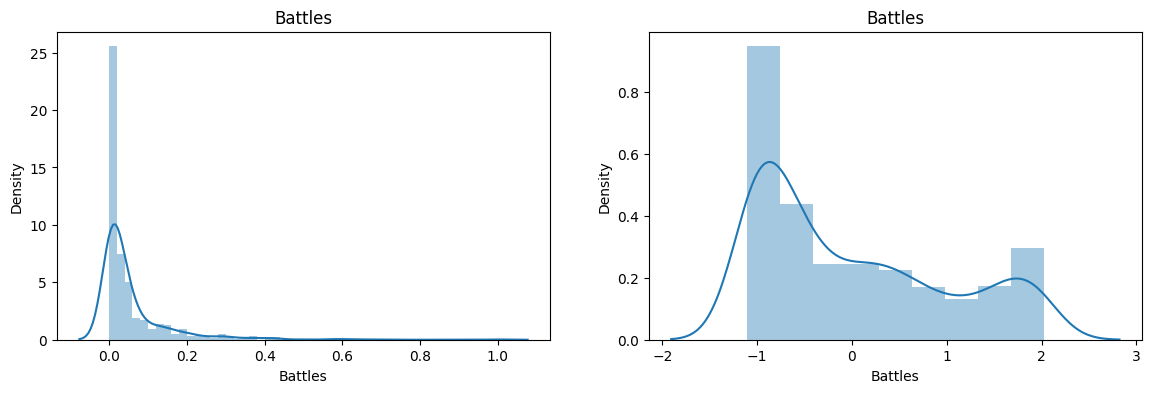

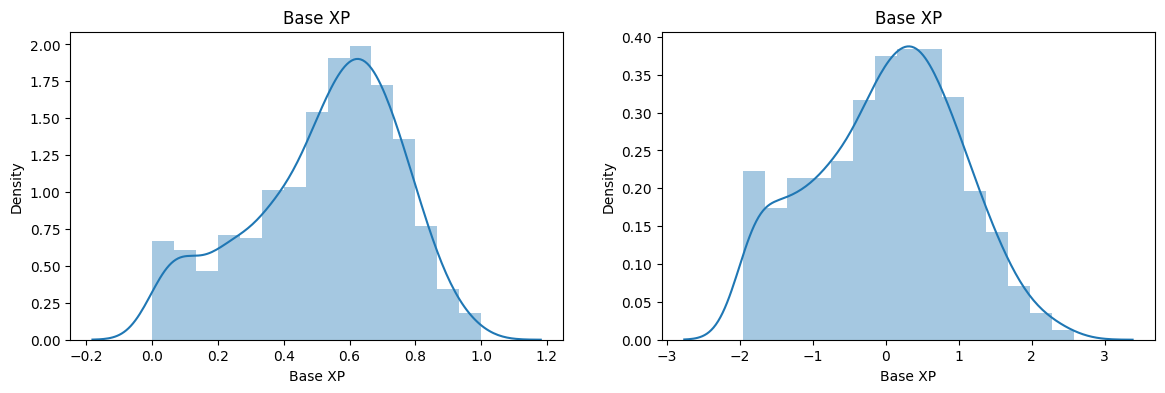

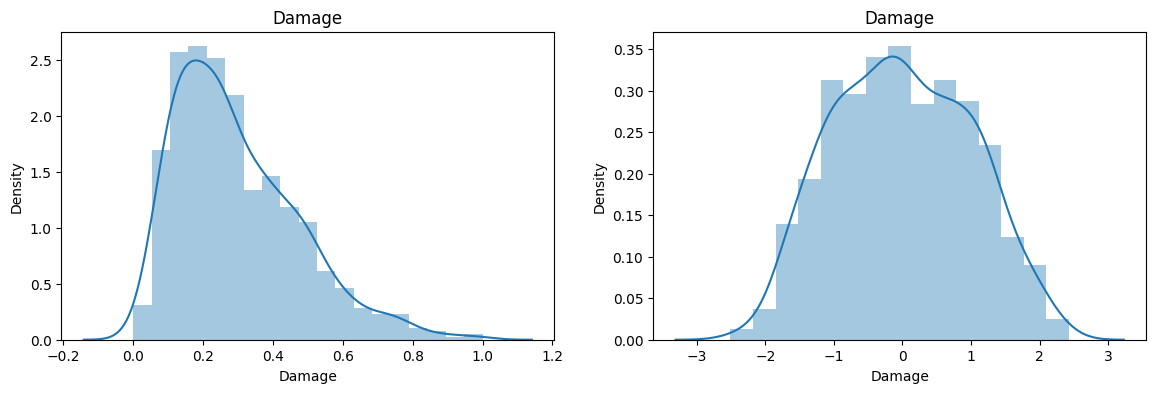

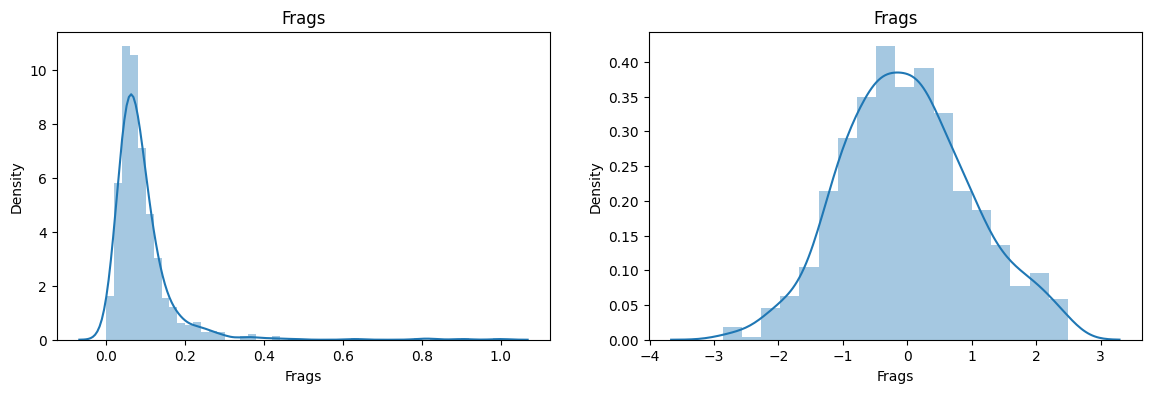

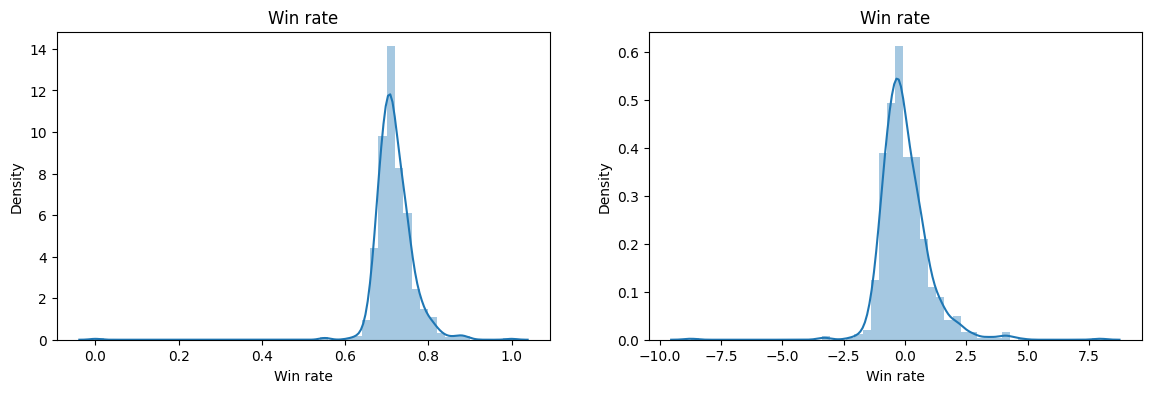

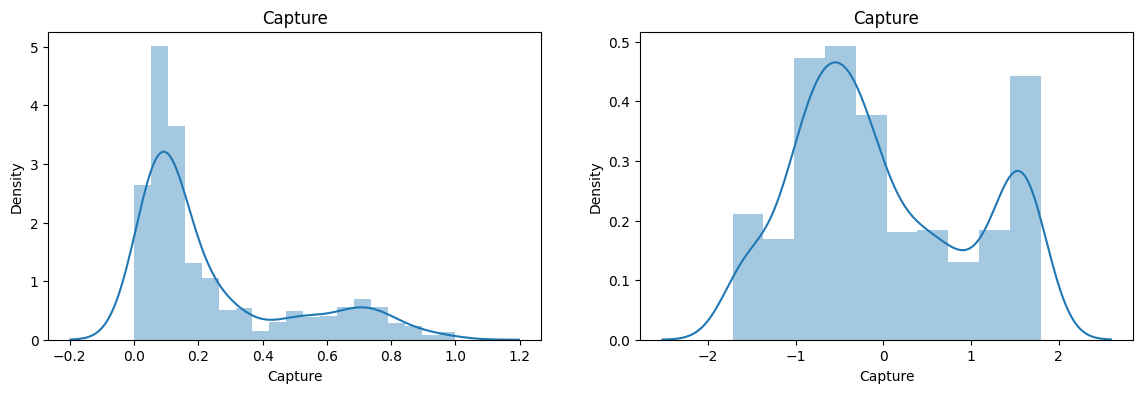

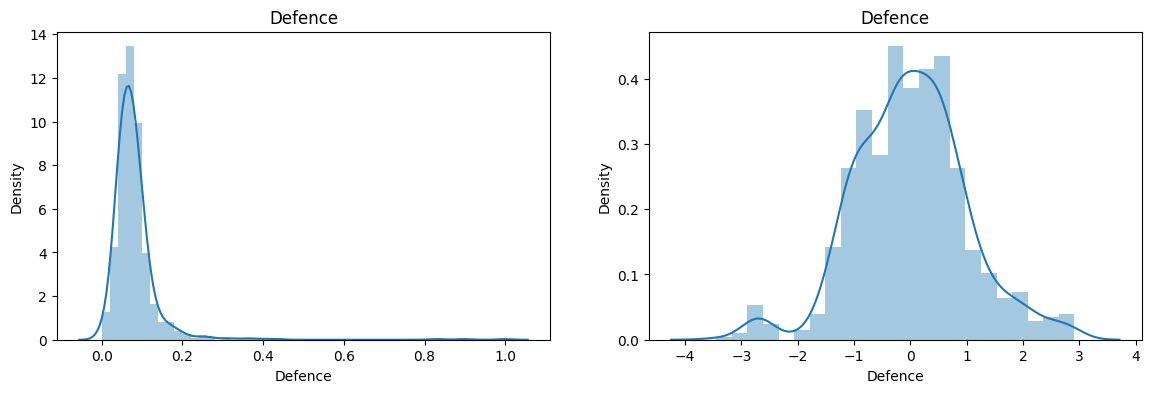

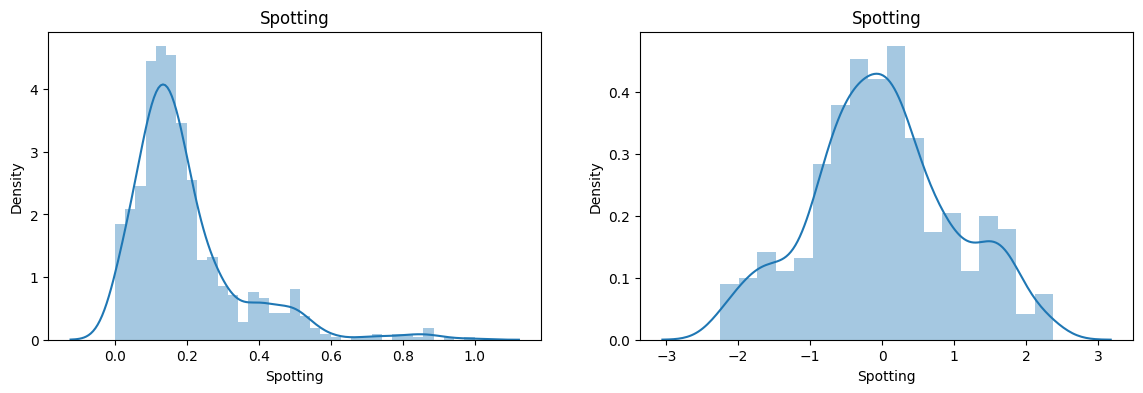

In [30]:
# Before and After Camparison of Yeo-Johnson

for col in x_train.columns:
  mt.figure(figsize = (14,4))
  mt.subplot(1,2,1)
  sns.distplot(x_train_scaled1[col])
  mt.title(col)

  mt.subplot(1,2,2)
  sns.distplot(x_train_transformed2[col])
  mt.title(col)
  mt.show


In [32]:
# Side by Side Lamdas

pd.DataFrame({'cols':x_train.columns,'Box-Cox':pt.lambdas_,'Yeo-Johnson':pt2.lambdas_})

,cols,Box-Cox,Yeo-Johnson
0,Battles,0.131451,-9.634896
1,Base XP,1.662217,1.226578
2,Damage,0.070234,-2.065773
3,Frags,-3.659980,-7.152704
4,Win rate,4.359690,-1.619189
5,Capture,-0.072235,-4.854678
6,Defence,-0.091564,-5.479604
7,Spotting,0.303744,-4.835962


In [31]:
print('''
Observation :

1. This transformer made the model performance worse than the normal data.

2. Sometimes transformers do not work as expected on every dataset.

3. If a transformer improves model performance, we can use it.
   Otherwise, we should remove or avoid it.

4. Transformers are not always necessary.
   Some models perform better on original or simply scaled data.

''')


Observation :

1. This transformer made the model performance worse than the normal data.

2. Sometimes transformers do not work as expected on every dataset.

3. If a transformer improves model performance, we can use it.
   Otherwise, we should remove or avoid it.

4. Transformers are not always necessary.
   Some models perform better on original or simply scaled data.


